# Risk exposure and accountable actions

Financial exposure and ordinal risk scores answer different questions. Correlations and uncertainty mean expected exposure is not automatically a contingency budget.

In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))


In [2]:
import pandas as pd
from src.risk import assess_risks
r=assess_risks(pd.read_csv('data/processed/risks.csv'))
display(r[['risk_id','probability','impact_gbp','exposure_gbp','score','RAG','owner','mitigation','due_date']].sort_values('exposure_gbp',ascending=False))

,risk_id,probability,impact_gbp,exposure_gbp,score,RAG,owner,mitigation,due_date
0,R01,0.65,8000000.0,5200000.0,20,RED,Construction manager,Agree alternative possession windows,2026-08-17
1,R02,0.55,5000000.0,2750000.0,12,AMBER,Supply chain manager,Reserve approved alternate supplier,2026-08-24
5,R06,0.40,6000000.0,2400000.0,8,AMBER,Systems manager,Early test rig integration,2026-09-14
3,R04,0.30,7000000.0,2100000.0,10,AMBER,Assurance manager,Independent assurance readiness review,2026-09-07
2,R03,0.35,3000000.0,1050000.0,6,GREEN,Design manager,Close design interface reviews,2026-08-31
4,R05,0.20,4000000.0,800000.0,4,GREEN,Geotechnical lead,Targeted ground investigation,2026-08-10


owner
Construction manager    5200000.0
Supply chain manager    2750000.0
Systems manager         2400000.0
Assurance manager       2100000.0
Design manager          1050000.0
Geotechnical lead        800000.0
Name: exposure_gbp, dtype: float64

SIMULATED aggregate expected exposure 14300000.0


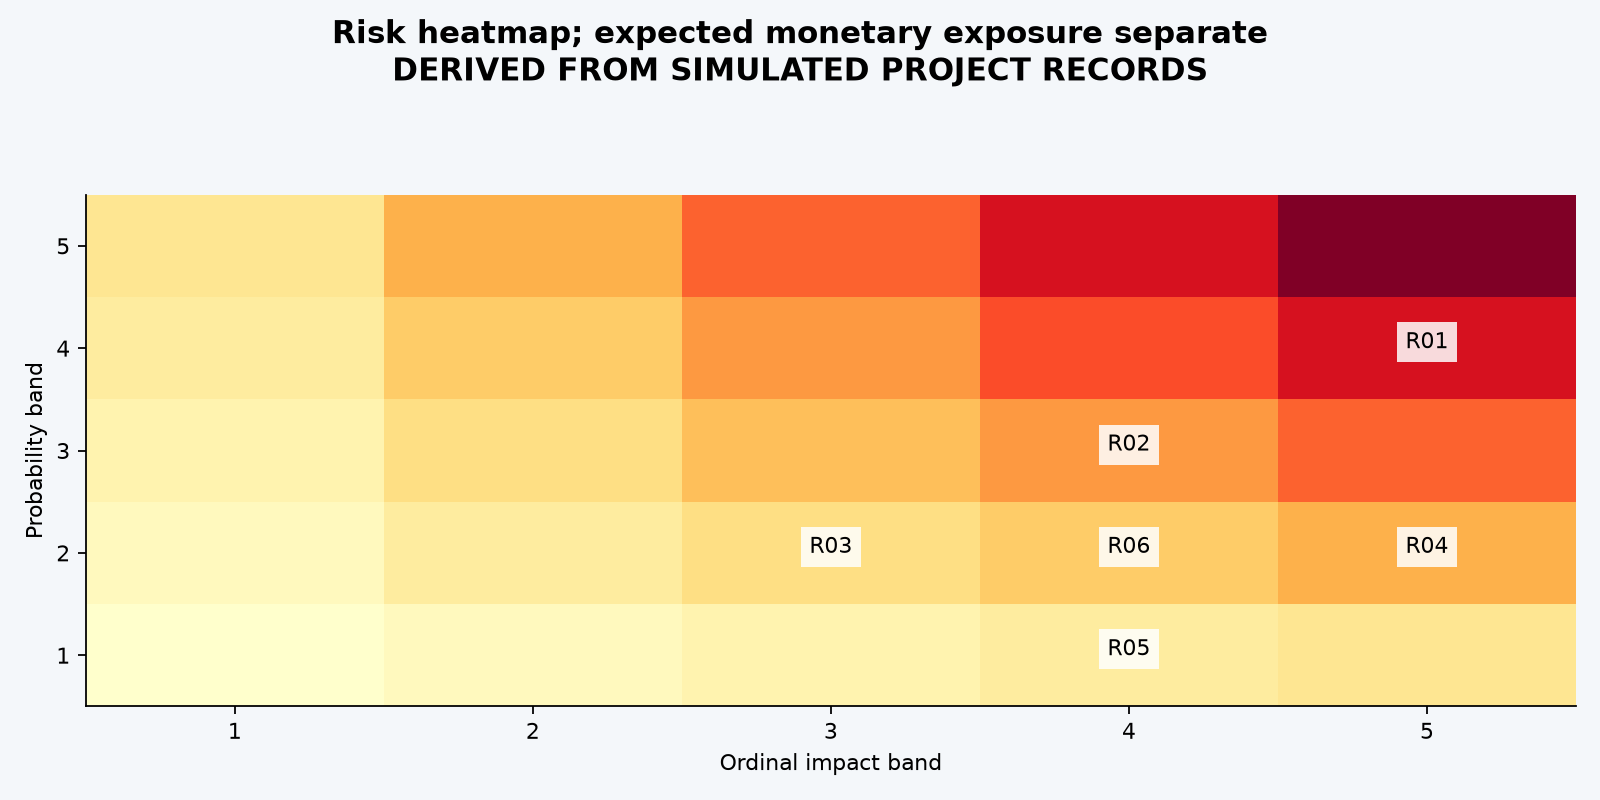

In [3]:
display(r.groupby('owner').exposure_gbp.sum().sort_values(ascending=False))
print('SIMULATED aggregate expected exposure',r.exposure_gbp.sum())
from IPython.display import Image,display
display(Image('figures/05_risk.png'))